# Knee Injuries Classification Project
## MRNet Classifier Notebook --> TRAINING A Multi-View 2D-CNN with a Transformer Head

- Use a shared ResNet-18 for all three views.
- Concatenate the features from Axial, Coronal, and Sagittal views into one long vector.
- Use a Transformer Encoder layer (Self-Attention) to let the model decide which slices and which views are the most important for the diagnosis.
- Using a weighted loss --> if acl tears are 4x as less likely as non-acl tears, penalize missing acl tears 4x as much

### Data source:
#### Stanford AIMI. (2026). MRNet: Knee MRI's (Version 1.0) [Dataset]. Redivis. https://stanford.redivis.com/datasets/4a2c-4cpkzrn2c?v=1.0


In [3]:
# MRNet Environment Setup (Run this cell first)
from google.colab import drive
import sys
import os
import zipfile
import shutil

### Only use the following code when you want to add the zipped folder to your drive.
This might take up to 40 minutes to run but it is a one time thing. If you can somehow create the .zip folder in your drive than you do not need to run this code.

In [5]:
drive.mount('/content/drive')
# 1. Define paths
# SOURCE: Your mounted Google Drive folder

Mounted at /content/drive


In [3]:

# # since you might have the files in a subfolder, make sure to create a folder shortcut in your Drive for easier access
# shared_folder_path = '/content/drive/MyDrive/MLII Final/Data/mrnet_images'

# # DESTINATION: The local, ultra-fast Colab cloud SSD storage
# local_zip_path = '/content/drive/MyDrive/MLII Final/Data/mrnet_images.zip'

# print("Starting optimized compression onto local cloud SSD...")

# # 2. Zip from Drive directly to the local cloud SSD
# !zip -rq "{local_zip_path}" "{shared_folder_path}"

# print("Compression to local SSD complete! Now uploading the single file back to your Drive...")

# # # 3. Copy the single large zip back to Google Drive in one efficient burst
# # !cp "{local_zip_path}" "/content/drive/MyDrive/"

# print("All done! Your optimized 'mrnet_images.zip' is now saved in your Google Drive.")

Starting optimized compression onto local cloud SSD...
Compression to local SSD complete! Now uploading the single file back to your Drive...
All done! Your optimized 'mrnet_images.zip' is now saved in your Google Drive.


### Loading data into colab SSD
When we already have your zip folder, we can start from here to git the data unziped inside the colab SSD.

In [4]:
# 1. Mount persistent storage
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
zip_source = '/content/drive/MyDrive/MLII Final/Data/mrnet_images.zip'

# 2. Point to the LOCAL Colab environment for the copy destination
zip_local = '/content/mrnet_images.zip'

# 3. Where the final unzipped images should live
final_image_dir = '/content/mrnet_images'
extract_to = '/content/'

# ==========================================
# RUN EXTRACTION SEQUENCE
# ==========================================
if not os.path.exists(final_image_dir):

    # Safety Check: Verify the zip file actually exists on Drive
    if not os.path.exists(zip_source):
        raise FileNotFoundError(f"Could not find your zip file at: {zip_source}. Double check the file name extension!")

    # Step A: Copy the zip from Drive to local SSD if it's missing
    if not os.path.exists(zip_local):
        print("Transferring optimized archive from Drive to local cloud SSD...")
        shutil.copy(zip_source, zip_local)
        print("Transfer complete! Starting extraction...")

    # Step B: Unzip with the visible progress counter
    print("Opening zip archive securely...")
    with zipfile.ZipFile(zip_local, 'r') as zip_ref:
        files = zip_ref.namelist()
        total_files = len(files)
        print(f"Total files to extract: {total_files}")

        # Discover the top-level directory name inside the zip file dynamically
        # (Usually 'MRNet-v1.0/' or 'mrnet/')
        top_level_internal_dir = files[0].split('/')[0]

        for index, file in enumerate(files):
            zip_ref.extract(file, extract_to)
            if index % 500 == 0 and index > 0:
                print(f"-> Extracted {index}/{total_files} files... ({int(index/total_files*100)}%)")

    print("Unpacking complete!")

    # Step C: Fix the path nesting structure automatically
    # Dynamically maps whatever folder name was inside the zip straight to '/content/mrnet_images'
    internal_extracted_path = os.path.join('/content', top_level_internal_dir)

    if os.path.exists(internal_extracted_path):
        print(f"Correcting zip path nesting structure: Renaming {internal_extracted_path} to {final_image_dir}...")
        os.rename(internal_extracted_path, final_image_dir)

    # Step D: Clean up the local copy of the zip file to save SSD space
    if os.path.exists(zip_local):
        os.remove(zip_local)
        print("Temporary local zip cleared from scratch disk.")

    print("Environment Setup Perfected!")
else:
    print("Data already unpacked and ready on local SSD.")

Transferring optimized archive from Drive to local cloud SSD...
Transfer complete! Starting extraction...
Opening zip archive securely...
Total files to extract: 3580
-> Extracted 500/3580 files... (13%)
-> Extracted 1000/3580 files... (27%)
-> Extracted 1500/3580 files... (41%)
-> Extracted 2000/3580 files... (55%)
-> Extracted 2500/3580 files... (69%)
-> Extracted 3000/3580 files... (83%)
-> Extracted 3500/3580 files... (97%)
Unpacking complete!
Correcting zip path nesting structure: Renaming /content/content to /content/mrnet_images...
Temporary local zip cleared from scratch disk.
Environment Setup Perfected!


### Importing .py file

In [11]:
import importlib
# 1. Clone the repository if it doesn't exist on the cloud machine yet
repo_path = '/content/CNN_ClassModeling'

if not os.path.exists(repo_path):
    print("Cloning the code repository from GitHub...")
    !git clone https://github.com/AbdulAlbaqami/Knee_Injuries_Classification_Model_MRI_Images.git {repo_path}
else:
    print("Repository already exists. Pulling latest updates...")
    !cd {repo_path} && git pull

# 2. Inject the repository path into Python's system search path
if repo_path not in sys.path:
    sys.path.append(repo_path)

# 3. Safe Module Import / Reload Logic
import loading_data as ld
# If teammates update the file and you pull it, this line forces Python to update its cache
importlib.reload(ld)

print("Successfully imported loading_data.py module!")

Cloning the code repository from GitHub...
Cloning into '/content/CNN_ClassModeling'...
remote: Enumerating objects: 27, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 27 (delta 8), reused 23 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (27/27), 535.86 KiB | 17.29 MiB/s, done.
Resolving deltas: 100% (8/8), done.
Successfully imported loading_data.py module!


In [46]:
import numpy as np

# Load a single case
sample_volume = np.load('/content/mrnet_images/drive/MyDrive/MLII Final/Data/mrnet_images/axial/0228.npy')

print("Data Type:", type(sample_volume))
print("Volume Shape:", sample_volume.shape)

Data Type: <class 'numpy.ndarray'>
Volume Shape: (24, 256, 256)


Array Shape: (26, 256, 256)


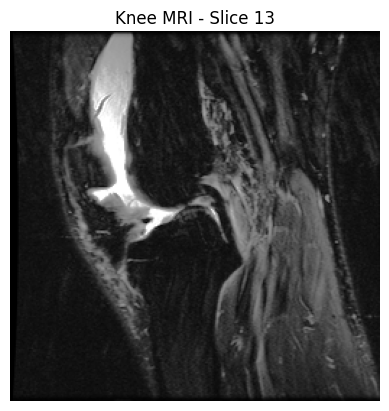

In [19]:
import matplotlib.pyplot as plt

# 1. Load one of your downloaded files (replace with your actual file path)
# Let's grab a random one from your sagittal or axial folder
mri_volume = np.load('/content/mrnet_images/drive/MyDrive/MLII Final/Data/mrnet_images/sagittal/0001.npy')

# 2. Check its dimensions
print("Array Shape:", mri_volume.shape)

# 3. Visualize a slice from the middle of the stack
middle_slice_idx = mri_volume.shape[0] // 2

plt.imshow(mri_volume[middle_slice_idx], cmap="gray")
plt.axis("off")
plt.title(f"Knee MRI - Slice {middle_slice_idx}")
plt.show()

### labels Data EDA

In [ ]:
import pandas as pd
label_data = pd.read_csv("/content/mrnet_images/labels/Redivis-files-2026-05-18.csv")
print(label_data.head())
print(label_data.columns)
print(label_data["Folder"].value_counts())
print(label_data.describe())


             Name Folder
0  axial/0000.npy  train
1  axial/0001.npy  train
2  axial/0002.npy  train
3  axial/0003.npy  train
4  axial/0004.npy  train
Index(['Name', 'Folder'], dtype='object')
Folder
train    3390
valid     360
Name: count, dtype: int64
                     Name Folder
count                3750   3750
unique               3750      2
top     sagittal/1249.npy  train
freq                    1   3390


In [20]:
import os
import numpy as np
from tqdm import tqdm

# Point this to one of your image folders (e.g., axial)
# All views (axial, coronal, sagittal) usually have very similar slice distributions
FOLDER_PATH = '/content/mrnet_images/drive/MyDrive/MLII Final/Data/mrnet_images/sagittal'

def calculate_slice_percentiles(folder_path):
    slice_counts = []

    # Get all .npy files in the directory
    files = [f for f in os.listdir(folder_path) if f.endswith('.npy')]

    print(f"Scanning {len(files)} files in {folder_path}...")

    for file in tqdm(files):
        file_path = os.path.join(folder_path, file)

        # mmap_mode='r' reads only the shape/metadata, saving massive amounts of RAM
        vol = np.load(file_path, mmap_mode='r')

        # vol.shape is (slices, height, width). We just want the first number.
        num_slices = vol.shape[0]
        slice_counts.append(num_slices)

    # Convert to numpy array for easy math
    slice_counts = np.array(slice_counts)

    # Calculate metrics
    avg_slices = np.mean(slice_counts)
    max_slices = np.max(slice_counts)
    min_slices = np.min(slice_counts)
    p90 = np.percentile(slice_counts, 90)
    p95 = np.percentile(slice_counts, 95)

    print("\n--- Slice Count Distribution ---")
    print(f"Minimum slices: {min_slices}")
    print(f"Average slices: {avg_slices:.1f}")
    print(f"Maximum slices: {max_slices}")
    print("--------------------------------")
    print(f"90th Percentile: {p90:.0f} slices")
    print(f"95th Percentile: {p95:.0f} slices")
    print("--------------------------------")
    print("Recommendation: Set your MAX_SLICES variable to the 90th or 95th percentile.")

# Run the function
calculate_slice_percentiles(FOLDER_PATH)

Scanning 1036 files in /content/mrnet_images/drive/MyDrive/MLII Final/Data/mrnet_images/sagittal...


100%|██████████| 1036/1036 [00:01<00:00, 653.98it/s]


--- Slice Count Distribution ---
Minimum slices: 17
Average slices: 30.2
Maximum slices: 51
--------------------------------
90th Percentile: 40 slices
95th Percentile: 42 slices
--------------------------------
Recommendation: Set your MAX_SLICES variable to the 90th or 95th percentile.


# Neural Network

In [33]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.models import resnet18, ResNet18_Weights
import matplotlib.pyplot as plt
from tqdm import tqdm

# ==========================================
# 1. CONFIGURATION
# ==========================================
BASE_DIR = '/content/mrnet_images/drive/MyDrive/MLII Final/Data/mrnet_images'
MASTER_CSV = os.path.join('/content/drive/MyDrive/MLII Final/Data/unified_labels.csv')

BATCH_SIZE = 2       # Keep small to avoid OOM
MAX_SLICES = 42    # Standardize slice counts
EPOCHS = 10
LEARNING_RATE = 1e-4
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [23]:
df = pd.read_csv(MASTER_CSV)

In [34]:
# ==========================================
# 2. DATASET & DATALOADER
# ==========================================
class MRNetDataset(Dataset):
    def __init__(self, base_dir, master_csv_path, split='train', subset_ratio=1.0, max_slices=35):
        self.base_dir = base_dir
        self.split = split
        self.max_slices = max_slices

        #only read in rows from csv file --> all the ids that have all three mris (axial, etc)
        df = pd.read_csv(master_csv_path) # Fallback to standard comma separated

        self.labels = df[df['split'] == split].copy()
        self.labels['exam_id'] = self.labels['exam_id'].astype(str).str.zfill(4)


        if subset_ratio < 1.0:
            self.labels = self.labels.sample(frac=subset_ratio, random_state=42).reset_index(drop=True)
            print(f"[{split.upper()}] Using {subset_ratio*100}% of data: {len(self.labels)} samples.")
        else:
            self.labels = self.labels.reset_index(drop=True)
            print(f"[{split.upper()}] Using 100% of data: {len(self.labels)} samples.")

        self.transform = T.Compose([
            T.ToPILImage(),
            T.Resize((224, 224)), #for resnet18
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def load_volume(self, path):
        vol = np.load(path)
        s, h, w = vol.shape

        #if the number of slices is greater than max slices, then it center crops (chops the first and last few)
        #if fewer than max slices, then it pads it by adding array of zeros (black images) to the end
        if s < self.max_slices:
            pad = np.zeros((self.max_slices - s, h, w), dtype=vol.dtype)
            vol = np.concatenate((vol, pad), axis=0)
        else:
            start = (s - self.max_slices) // 2
            vol = vol[start:start + self.max_slices]

        processed_vol = []

        #resnet18 wants rgb
        for i in range(self.max_slices):
            slice_3c = np.stack((vol[i],)*3, axis=-1).astype(np.uint8)
            processed_vol.append(self.transform(slice_3c))

        return torch.stack(processed_vol)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        row = self.labels.iloc[idx]
        pid = row['exam_id']

        if self.split == 'valid':
            ax_path = os.path.join(self.base_dir, 'valid_files', 'axial', f'{pid}.npy')
            cor_path = os.path.join(self.base_dir, 'valid_files', 'coronal', f'{pid}.npy')
            sag_path = os.path.join(self.base_dir, 'valid_files', 'sagittal', f'{pid}.npy')
        else:
            ax_path = os.path.join(self.base_dir, 'axial', f'{pid}.npy')
            cor_path = os.path.join(self.base_dir, 'coronal', f'{pid}.npy')
            sag_path = os.path.join(self.base_dir, 'sagittal', f'{pid}.npy')

        ax_vol = self.load_volume(ax_path)
        cor_vol = self.load_volume(cor_path)
        sag_vol = self.load_volume(sag_path)

        # Output order: ACL, Meniscus, Abnormal
        labels = torch.tensor([row['acl'], row['meniscus'], row['abnormal']], dtype=torch.float32)
        return ax_vol, cor_vol, sag_vol, labels

# Train on 10%, Validate on 100%
train_dataset = MRNetDataset(BASE_DIR, MASTER_CSV, split='train', subset_ratio=0.10, max_slices=MAX_SLICES)
valid_dataset = MRNetDataset(BASE_DIR, MASTER_CSV, split='valid', subset_ratio=1.0, max_slices=MAX_SLICES)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

[TRAIN] Using 10.0% of data: 94 samples.
[VALID] Using 100% of data: 119 samples.


In [25]:
#makesure dataloader was inputted correctly
dataiter = iter(train_loader)
ax, cor, sag, labels = next(dataiter)

dataiter = iter(valid_loader)
ax, cor, sag, labels = next(dataiter)

In [42]:
# ==========================================
# 3. MODEL ARCHITECTURE
# ==========================================
class MultiViewTransformer(nn.Module):
    def __init__(self, d_model=512, nhead=8, num_layers=1):
        super().__init__()
        resnet = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])

        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.head_acl = nn.Linear(d_model, 1)
        self.head_men = nn.Linear(d_model, 1)
        self.head_abn = nn.Linear(d_model, 1)

    def extract_features(self, x):
        B, S, C, H, W = x.shape
        x = x.view(B * S, C, H, W)
        features = self.backbone(x)
        return features.view(B, S, -1)

    def forward(self, ax, cor, sag):
        f_ax = self.extract_features(ax)
        f_cor = self.extract_features(cor)
        f_sag = self.extract_features(sag)

        # Concat along sequence dimension (slices)
        f_fused = torch.cat([f_ax, f_cor, f_sag], dim=1)
        f_trans = self.transformer(f_fused)
        f_pool = f_trans.mean(dim=1)

        return self.head_acl(f_pool), self.head_men(f_pool), self.head_abn(f_pool)

# ==========================================
# 4. KENDALL MULTI-TASK LOSS
# ==========================================
class KendallMultiTaskLoss(nn.Module):
    def __init__(self, num_tasks=3):
        super().__init__()
        self.log_vars = nn.Parameter(torch.zeros(num_tasks))
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, preds, targets):
        total_loss = 0
        for i in range(len(preds)):
            task_loss = self.bce(preds[i].squeeze(1), targets[:, i])
            precision = torch.exp(-self.log_vars[i])
            total_loss += precision * task_loss + 0.5 * self.log_vars[i]
        return total_loss


import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

# ==========================================
# 4. ALTERNATIVE CRITERION
# ==========================================
class StandardMultiTaskLoss(nn.Module):
    def __init__(self):
        super().__init__()
        # BCEWithLogitsLoss safely combines the Sigmoid activation and Cross Entropy Loss
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, preds, targets):
        # Simply calculate the loss for each task independently and sum them together.
        # This prevents the network from "cheating" the math like it can with Kendall.
        loss_acl = self.bce(preds[0].squeeze(1), targets[:, 0])
        loss_men = self.bce(preds[1].squeeze(1), targets[:, 1])
        loss_abn = self.bce(preds[2].squeeze(1), targets[:, 2])

        return loss_acl + loss_men + loss_abn

# ==========================================
# 4. Weighted loss CRITERION
#if acl tears are 4x less likely, it will penalize for missing acl tears 4x as much as non acl tears
# ==========================================
class WeightedMultiTaskLoss(nn.Module):
    def __init__(self, acl_w, men_w, abn_w):
        super().__init__()
        # We wrap the weights in tensors and move them to the GPU
        self.bce_acl = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([acl_w]).to(DEVICE))
        self.bce_men = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([men_w]).to(DEVICE))
        self.bce_abn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([abn_w]).to(DEVICE))

    def forward(self, preds, targets):
        # Using squeeze(1) to stay batch-size safe as discussed
        loss_acl = self.bce_acl(preds[0].squeeze(1), targets[:, 0])
        loss_men = self.bce_men(preds[1].squeeze(1), targets[:, 1])
        loss_abn = self.bce_abn(preds[2].squeeze(1), targets[:, 2])

        # Total loss is the sum of the three weighted tasks
        return loss_acl + loss_men + loss_abn



In [43]:
import torch
print(torch.cuda.is_available())

True


In [44]:
# ==========================================
# 5. TRAINING LOOP
# ==========================================
model = MultiViewTransformer().to(DEVICE)
# Swap in the new standard loss function here
ACL_WEIGHT = 4.0      # Missing an ACL tear is 4x as costly
MENISCUS_WEIGHT = 1.8 # Missing a Meniscus tear is 2x as costly
ABNORMAL_WEIGHT = 0.5 # Abnormality is more common, so weight is lower

criterion = WeightedMultiTaskLoss(
    acl_w=ACL_WEIGHT,
    men_w=MENISCUS_WEIGHT,
    abn_w=ABNORMAL_WEIGHT
).to(DEVICE)

#criterion = StandardMultiTaskLoss().to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Mixed precision scaler
scaler = torch.cuda.amp.GradScaler()

history = {
    # ACL
    'train_tot_acl': [], 'valid_tot_acl': [],
    'train_tear_acl': [], 'train_non_acl': [], 'valid_tear_acl': [], 'valid_non_acl': [],

    # Meniscus
    'train_tot_men': [], 'valid_tot_men': [],
    'train_tear_men': [], 'train_non_men': [], 'valid_tear_men': [], 'valid_non_men': [],

    # Abnormality
    'train_tot_abn': [], 'valid_tot_abn': [],
    'train_tear_abn': [], 'train_non_abn': [], 'valid_tear_abn': [], 'valid_non_abn': [],
}

def calc_all_metrics(outputs, targets):
    preds = (torch.sigmoid(outputs.squeeze(1)) > 0.5).float()

    # 1. Overall
    correct_total = (preds == targets).float().sum().item()
    total = targets.size(0)

    # 2. Isolate the groups
    tear_mask = (targets == 1)
    nontear_mask = (targets == 0)

    # 3. Class splits
    correct_tears = (preds[tear_mask] == 1).float().sum().item()
    total_tears = tear_mask.float().sum().item()

    correct_nontears = (preds[nontear_mask] == 0).float().sum().item()
    total_nontears = nontear_mask.float().sum().item()

    return [correct_total, total, correct_tears, total_tears, correct_nontears, total_nontears]

for epoch in range(EPOCHS):
    # --- TRAIN ---
    model.train()

    # Lists to hold: [c_tot, t_tot, c_tear, t_tear, c_non, t_non]
    tr_stats_acl = [0] * 6
    tr_stats_men = [0] * 6
    tr_stats_abn = [0] * 6

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
    for ax, cor, sag, labels in loop:
        ax, cor, sag, labels = ax.to(DEVICE), cor.to(DEVICE), sag.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            out_acl, out_men, out_abn = model(ax, cor, sag)
            loss = criterion([out_acl, out_men, out_abn], labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Calculate metrics for this batch
        batch_acl = calc_all_metrics(out_acl, labels[:, 0])
        batch_men = calc_all_metrics(out_men, labels[:, 1])
        batch_abn = calc_all_metrics(out_abn, labels[:, 2])

        # Accumulate stats
        tr_stats_acl = [a + b for a, b in zip(tr_stats_acl, batch_acl)]
        tr_stats_men = [a + b for a, b in zip(tr_stats_men, batch_men)]
        tr_stats_abn = [a + b for a, b in zip(tr_stats_abn, batch_abn)]

        loop.set_postfix(loss=loss.item())

    # Append Train Metrics to History
    history['train_tot_acl'].append(tr_stats_acl[0] / max(1, tr_stats_acl[1]))
    history['train_tear_acl'].append(tr_stats_acl[2] / max(1, tr_stats_acl[3]))
    history['train_non_acl'].append(tr_stats_acl[4] / max(1, tr_stats_acl[5]))

    history['train_tot_men'].append(tr_stats_men[0] / max(1, tr_stats_men[1]))
    history['train_tear_men'].append(tr_stats_men[2] / max(1, tr_stats_men[3]))
    history['train_non_men'].append(tr_stats_men[4] / max(1, tr_stats_men[5]))

    history['train_tot_abn'].append(tr_stats_abn[0] / max(1, tr_stats_abn[1]))
    history['train_tear_abn'].append(tr_stats_abn[2] / max(1, tr_stats_abn[3]))
    history['train_non_abn'].append(tr_stats_abn[4] / max(1, tr_stats_abn[5]))

    # --- VALIDATION ---
    model.eval()
    val_stats_acl = [0] * 6
    val_stats_men = [0] * 6
    val_stats_abn = [0] * 6

    with torch.no_grad():
        for ax, cor, sag, labels in tqdm(valid_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Valid]"):
            ax, cor, sag, labels = ax.to(DEVICE), cor.to(DEVICE), sag.to(DEVICE), labels.to(DEVICE)

            with torch.cuda.amp.autocast():
                out_acl, out_men, out_abn = model(ax, cor, sag)

            # Calculate metrics for this batch
            batch_acl = calc_all_metrics(out_acl, labels[:, 0])
            batch_men = calc_all_metrics(out_men, labels[:, 1])
            batch_abn = calc_all_metrics(out_abn, labels[:, 2])

            # Accumulate stats
            val_stats_acl = [a + b for a, b in zip(val_stats_acl, batch_acl)]
            val_stats_men = [a + b for a, b in zip(val_stats_men, batch_men)]
            val_stats_abn = [a + b for a, b in zip(val_stats_abn, batch_abn)]

    # Append Validation Metrics to History
    history['valid_tot_acl'].append(val_stats_acl[0] / max(1, val_stats_acl[1]))
    history['valid_tear_acl'].append(val_stats_acl[2] / max(1, val_stats_acl[3]))
    history['valid_non_acl'].append(val_stats_acl[4] / max(1, val_stats_acl[5]))

    history['valid_tot_men'].append(val_stats_men[0] / max(1, val_stats_men[1]))
    history['valid_tear_men'].append(val_stats_men[2] / max(1, val_stats_men[3]))
    history['valid_non_men'].append(val_stats_men[4] / max(1, val_stats_men[5]))

    history['valid_tot_abn'].append(val_stats_abn[0] / max(1, val_stats_abn[1]))
    history['valid_tear_abn'].append(val_stats_abn[2] / max(1, val_stats_abn[3]))
    history['valid_non_abn'].append(val_stats_abn[4] / max(1, val_stats_abn[5]))

/tmp/ipykernel_3796/4138858629.py:20: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
Epoch 1/10 [Train]:   0%|          | 0/47 [00:00<?, ?it/s]/tmp/ipykernel_3796/4138858629.py:71: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/10 [Valid]:   0%|          | 0/60 [00:00<?, ?it/s]/tmp/ipykernel_3796/4138858629.py:114: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 10/10 [Valid]: 100%|██████████| 60/60 [00:42<00:00,  1.41it/s]


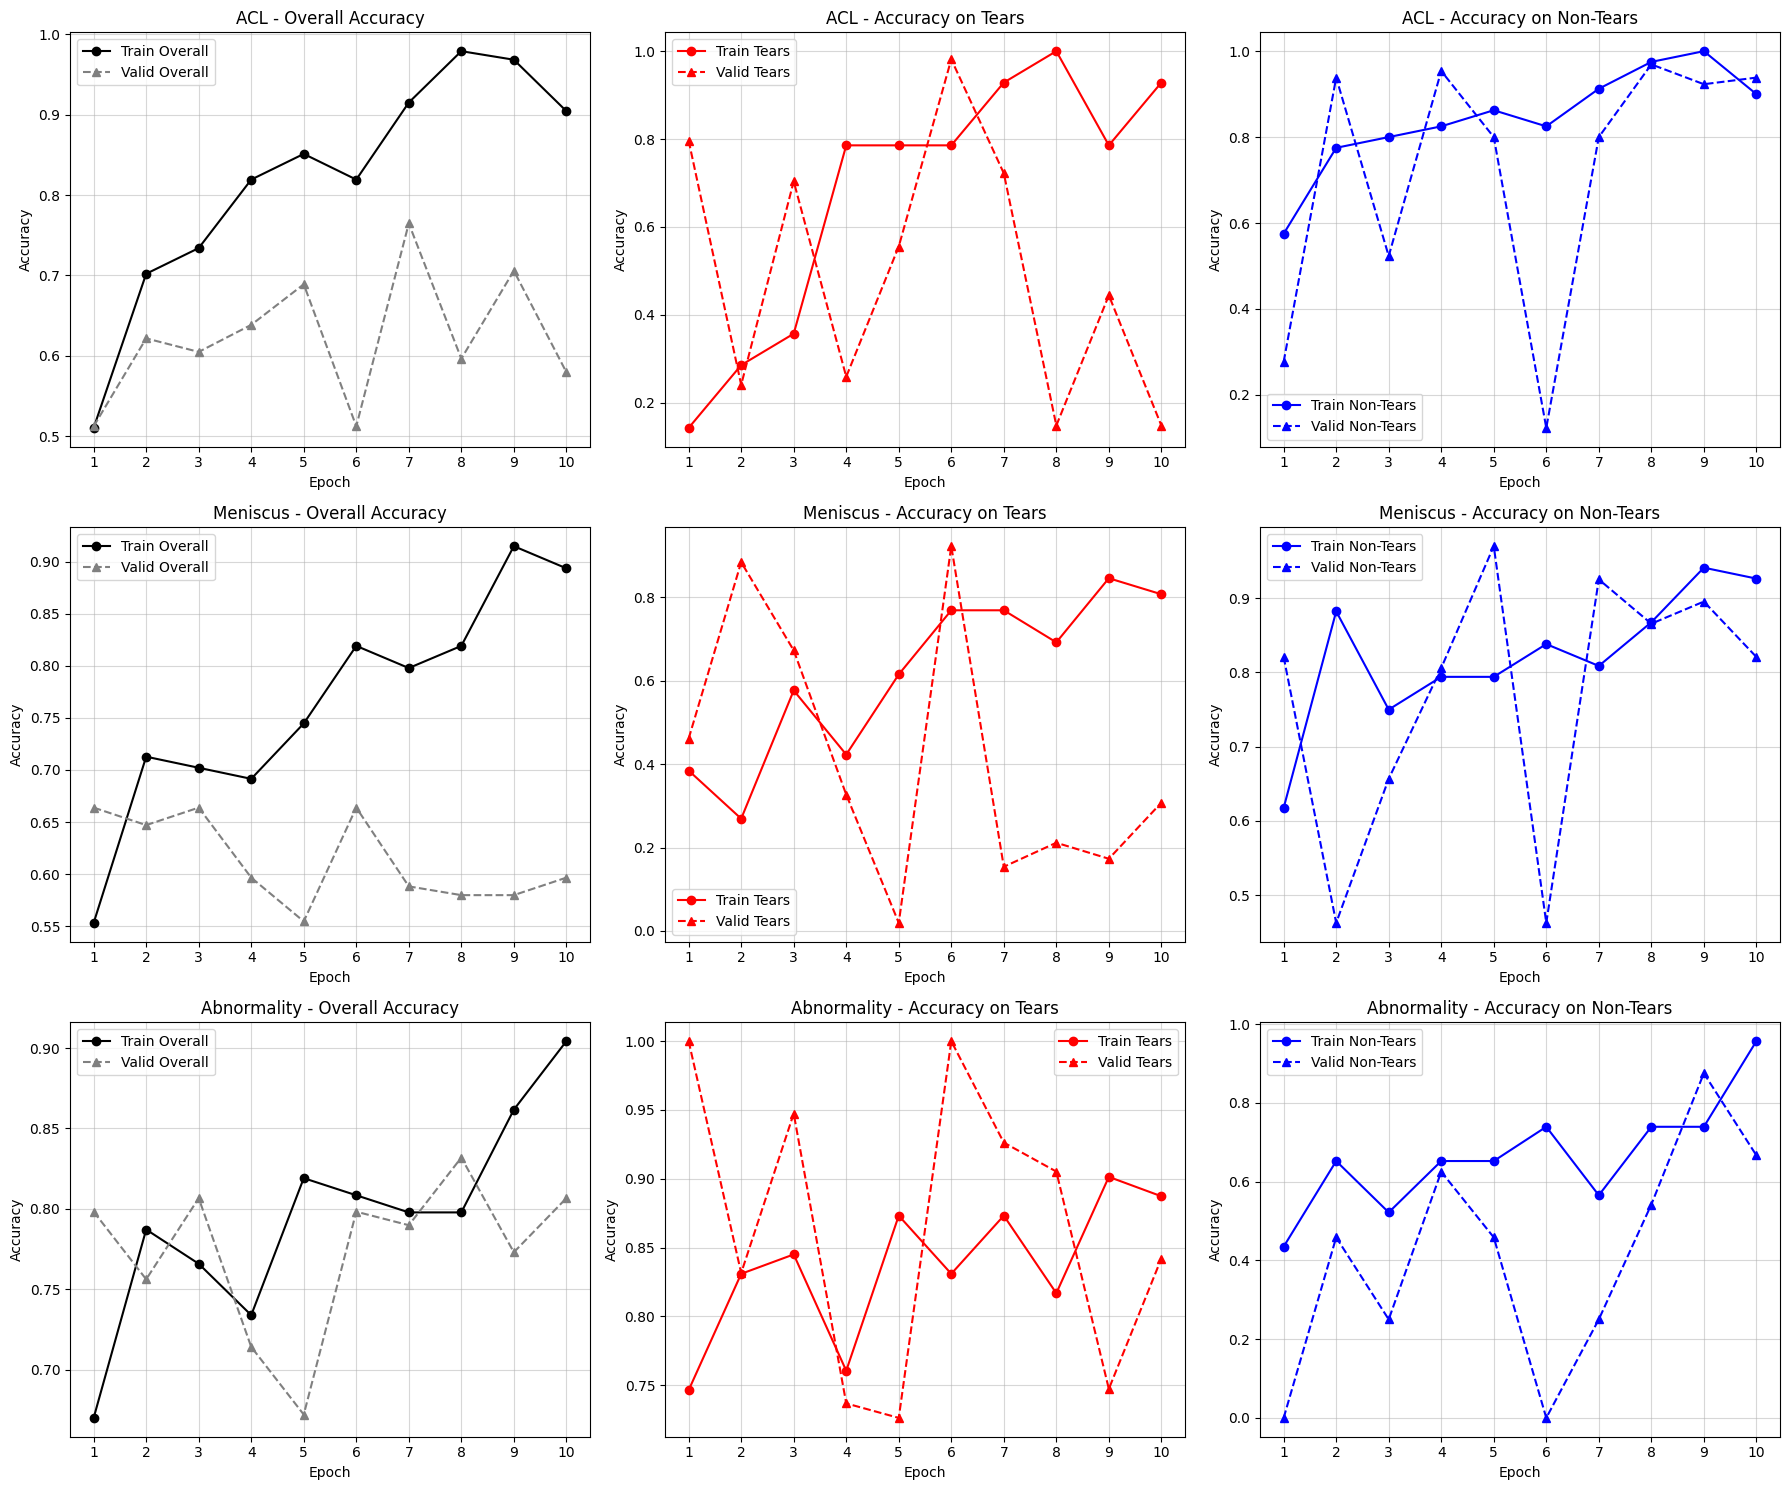

In [45]:
# ==========================================
# 6. VISUALIZATION (3x3 GRID)
# ==========================================
def plot_metrics(history, epochs):
    # Create a 3-row, 3-column grid
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))
    x_axis = range(1, epochs + 1)

    # Map the display title to the suffix used in the history dictionary keys
    tasks = [
        ('ACL', 'acl'),
        ('Meniscus', 'men'),
        ('Abnormality', 'abn')
    ]

    for row, (title, suffix) in enumerate(tasks):

        # ---------------------------------------------------
        # CHART 1: OVERALL ACCURACY (Left Column)
        # ---------------------------------------------------
        ax_tot = axes[row, 0]
        ax_tot.plot(x_axis, history[f'train_tot_{suffix}'], label='Train Overall', color='black', marker='o')
        ax_tot.plot(x_axis, history[f'valid_tot_{suffix}'], label='Valid Overall', color='gray', linestyle='--', marker='^')

        ax_tot.set_title(f'{title} - Overall Accuracy')
        ax_tot.set_xlabel('Epoch')
        ax_tot.set_ylabel('Accuracy')
        ax_tot.set_xticks(x_axis)
        ax_tot.legend()
        ax_tot.grid(True, alpha=0.5)

        # ---------------------------------------------------
        # CHART 2: TEAR ACCURACY ONLY (Middle Column)
        # ---------------------------------------------------
        ax_tear = axes[row, 1]
        ax_tear.plot(x_axis, history[f'train_tear_{suffix}'], label='Train Tears', color='red', linestyle='-', marker='o')
        ax_tear.plot(x_axis, history[f'valid_tear_{suffix}'], label='Valid Tears', color='red', linestyle='--', marker='^')

        ax_tear.set_title(f'{title} - Accuracy on Tears')
        ax_tear.set_xlabel('Epoch')
        ax_tear.set_ylabel('Accuracy')
        ax_tear.set_xticks(x_axis)
        ax_tear.legend()
        ax_tear.grid(True, alpha=0.5)

        # ---------------------------------------------------
        # CHART 3: NON-TEAR ACCURACY ONLY (Right Column)
        # ---------------------------------------------------
        ax_non = axes[row, 2]
        ax_non.plot(x_axis, history[f'train_non_{suffix}'], label='Train Non-Tears', color='blue', linestyle='-', marker='o')
        ax_non.plot(x_axis, history[f'valid_non_{suffix}'], label='Valid Non-Tears', color='blue', linestyle='--', marker='^')

        ax_non.set_title(f'{title} - Accuracy on Non-Tears')
        ax_non.set_xlabel('Epoch')
        ax_non.set_ylabel('Accuracy')
        ax_non.set_xticks(x_axis)
        ax_non.legend()
        ax_non.grid(True, alpha=0.5)

    plt.tight_layout()
    plt.show()

# Run the plot
plot_metrics(history, EPOCHS)